#機械学習の勉強　--練習問題

In [10]:
'''
#9-1
購入した顧客，購入しなかった顧客を分類する決定木モデルを作成する。

#9-2
・購入するか否かに大きな影響を与える要素を特定できる
・顧客の情報から購入するか否かを予測できる。
ゆえに、購入する可能性が高い顧客にターゲットを絞って接触することが可能になり、営業や広告の費用対効果を向上させられる。
'''

'\n#9-1\n購入した顧客，購入しなかった顧客を分類する決定木モデルを作成する。\n\n#9-2\n・購入するか否かに大きな影響を与える要素を特定できる\n・顧客の情報から購入するか否かを予測できる。\nゆえに、購入する可能性が高い顧客にターゲットを絞って接触することが可能になり、営業や広告の費用対効果を向上させられる。\n'

In [11]:
#9-3
import pandas as pd
from sklearn import tree
from sklearn.model_selection import train_test_split

df=pd.read_csv(r'C:\Users\natsu\Desktop\machine_learning\datafiles\Bank.csv')
display(df.head(5))

display(df.isnull().sum())


,id,age,job,marital,education,default,amount,housing,loan,contact,day,month,duration,campaign,previous,y
0,1,39,blue-collar,married,secondary,no,1756.0,yes,no,cellular,3,apr,370.055237,1,0,1
1,2,51,entrepreneur,married,primary,no,1443.0,no,no,cellular,18,feb,233.998933,10,0,1
2,3,36,management,single,tertiary,no,436.0,no,no,cellular,13,apr,NaN,1,2,0
3,4,63,retired,married,secondary,no,474.0,no,no,cellular,25,jan,252.525808,1,0,0
4,5,31,management,single,tertiary,no,354.0,no,no,cellular,30,apr,NaN,1,2,0


id              0
age             0
job             0
marital         0
education       0
default         0
amount          0
housing         0
loan            0
contact         0
day             0
month           0
duration     7044
campaign        0
previous        0
y               0
dtype: int64

In [12]:
df_cols=df.columns
for col in df_cols:
    display(df[col].value_counts())

id
1        1
18069    1
18093    1
18092    1
18091    1
        ..
9040     1
9039     1
9038     1
9037     1
27128    1
Name: count, Length: 27128, dtype: int64

age
32    1232
33    1211
31    1205
35    1175
34    1129
      ... 
90       1
87       1
89       1
95       1
94       1
Name: count, Length: 77, dtype: int64

job
blue-collar      5886
management       5620
technician       4491
admin.           3085
services         2506
retired          1391
self-employed     945
entrepreneur      914
unemployed        790
housemaid         765
student           557
unknown           178
Name: count, dtype: int64

marital
married     16411
single       7662
divorced     3055
Name: count, dtype: int64

education
secondary    13882
tertiary      7959
primary       4150
unknown       1137
Name: count, dtype: int64

...

month
may    8317
jul    4136
aug    3718
jun    3204
nov    2342
apr    1755
feb    1586
jan     846
oct     439
sep     356
mar     299
dec     130
Name: count, dtype: int64

duration
370.055237    1
318.263212    1
259.134910    1
454.573894    1
380.418575    1
             ..
239.179383    1
406.563430    1
283.798189    1
242.811674    1
321.215556    1
Name: count, Length: 20084, dtype: int64

campaign
1     10555
2      7599
3      3295
4      2070
5      1021
6       762
7       445
8       319
9       195
10      161
11      115
12       96
13       80
14       56
16       43
15       42
17       37
18       32
19       30
20       25
21       23
24       14
22       14
25       11
28       11
29        9
27        9
23        9
31        8
26        6
30        5
32        4
34        4
33        4
36        3
37        2
35        2
38        2
63        1
41        1
50        1
58        1
46        1
43        1
55        1
51        1
39        1
44        1
Name: count, dtype: int64

previous
0      22146
1       1684
2       1273
3        689
4        445
5        264
6        166
7        117
8         82
9         50
10        45
11        31
13        27
12        24
15        15
14        12
19         8
17         8
16         6
20         5
27         4
22         4
23         3
21         3
29         3
25         3
24         2
18         2
275        1
55         1
38         1
41         1
51         1
40         1
28         1
Name: count, dtype: int64

y
0    18445
1     8683
Name: count, dtype: int64

In [13]:
#jobの欠損値補完
mode = df.loc[df['job'] != 'unknown', 'job'].mode()[0]
df['job'] = df['job'].replace('unknown', mode)

In [14]:
#名義尺度のダミー変数化
to_dummies=['job','marital','default','housing','loan','contact']
for col in to_dummies:
    dummied=pd.get_dummies(df[col],drop_first=True,dtype=int)
    df=pd.concat([df,dummied],axis=1)
    df=df.drop(col,axis=1)

display(df.head(5).T)

,0,1,2,3,4
id,1,2,3,4,5
age,39,51,36,63,31
education,secondary,primary,tertiary,secondary,tertiary
amount,1756.0,1443.0,436.0,474.0,354.0
day,3,18,13,25,30
month,apr,feb,apr,jan,apr
duration,370.055237,233.998933,NaN,252.525808,NaN
campaign,1,10,1,1,1
previous,0,0,2,0,2
y,1,1,0,0,0


In [15]:

#列名のうち重複しているものを変更
df.columns=['id', 'age', 'education','amount', 'day', 'month','duration', 'campaign', 'previous', 'y',
       'blue-collar', 'entrepreneur', 'housemaid', 'management', 'retired',
       'self-employed', 'services', 'student', 'technician', 'unemployed',
       'married', 'single', 'default', 'housing', 'loan',
       'sending _document', 'telephone']


cols=df.columns
for col in cols:
    display(df[[col]].value_counts())

id   
1        1
18069    1
18093    1
18092    1
18091    1
        ..
9040     1
9039     1
9038     1
9037     1
27128    1
Name: count, Length: 27128, dtype: int64

age
32     1232
33     1211
31     1205
35     1175
34     1129
       ... 
89        1
90        1
93        1
94        1
95        1
Name: count, Length: 77, dtype: int64

education
secondary    13882
tertiary      7959
primary       4150
unknown       1137
Name: count, dtype: int64

amount  
0.0         2059
449.0        283
1.0          124
3.0           94
2.0           83
            ... 
3492.0         1
3493.0         1
3495.0         1
3501.0         1
102127.0       1
Name: count, Length: 5868, dtype: int64

day
20     1612
18     1345
21     1233
17     1192
6      1145
5      1123
8      1099
14     1095
28     1091
7      1091
29     1060
19     1040
15     1017
12      969
9       964
30      956
13      947
11      909
4       878
16      841
2       781
27      689
3       672
26      604
23      566
22      537
25      520
31      378
10      308
24      278
1       188
Name: count, dtype: int64

...

default
0          26644
1            484
Name: count, dtype: int64

housing
1          15125
0          12003
Name: count, dtype: int64

loan
0       22788
1        4340
Name: count, dtype: int64

sending _document
0                    19267
1                     7861
Name: count, dtype: int64

telephone
0            25441
1             1687
Name: count, dtype: int64

In [16]:

#順序尺度のダミー変数化
#education,monthは順序尺度
#educationのunknownは最頻値で補完

educations={
    'primary':1,
    'secondary':2,
    'tertiary':3
}

mode = df.loc[df['education'] != 'unknown', 'education'].mode()[0]
to_unknown=educations[str(mode)]

education_map={
    'unknown':to_unknown,
    'primary':1,
    'secondary':2,
    'tertiary':3
}
df['education']=df['education'].map(education_map)

month_map={
    'jan':1,
    'feb':2,
    'mar':3,
    'apr':4,
    'may':5,
    'jun':6,
    'jul':7,
    'aug':8,
    'sep':9,
    'oct':10,
    'nov':11,
    'dec':12
}

df['month']=df['month'].map(month_map)

In [17]:
display(df.head(10).T)

,0,1,2,3,4,5,6,7,8,9
id,1.000000,2.000000,3.0,4.000000,5.0,6.000000,7.000000,8.00000,9.000000,10.000000
age,39.000000,51.000000,36.0,63.000000,31.0,29.000000,37.000000,32.00000,31.000000,32.000000
education,2.000000,1.000000,3.0,2.000000,3.0,2.000000,2.000000,2.00000,2.000000,3.000000
amount,1756.000000,1443.000000,436.0,474.000000,354.0,260.000000,52.000000,449.00000,0.000000,1815.000000
day,3.000000,18.000000,13.0,25.000000,30.0,2.000000,6.000000,18.00000,7.000000,10.000000
month,4.000000,2.000000,4.0,1.000000,4.0,6.000000,9.000000,5.00000,5.000000,8.000000
duration,370.055237,233.998933,NaN,252.525808,NaN,238.385368,350.269989,359.91213,292.503403,184.903837
campaign,1.000000,10.000000,1.0,1.000000,1.0,14.000000,1.000000,1.00000,2.000000,1.000000
previous,0.000000,0.000000,2.0,0.000000,2.0,0.000000,9.000000,8.00000,2.000000,2.000000
y,1.000000,1.000000,0.0,0.000000,0.0,0.000000,1.000000,0.00000,0.000000,0.000000


In [18]:
#テストデータの分離
train_val,test=train_test_split(df,test_size=0.2,random_state=0)

In [19]:
df.shape

(27128, 27)

<Axes: >

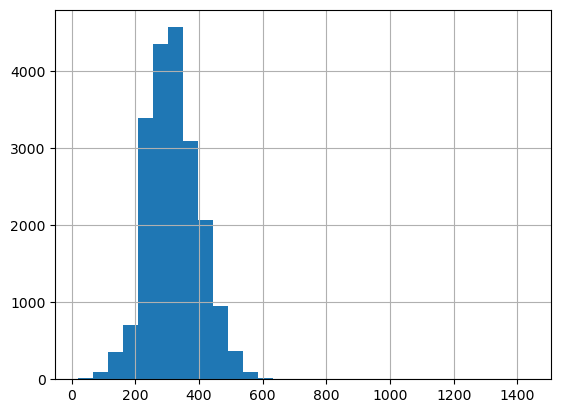

In [20]:
#durationが欠損している人にどのような特徴があるか調べる
df['duration_missing'] = df['duration'].isna()
df['duration'].hist(bins=30)    #ヒストグラムを書く


In [21]:
#durationが欠損している人にどのような特徴があるか調べる
display(df.groupby('duration_missing').mean(numeric_only=True).T)    #平均

duration_missing,False,True
id,13572.603764,13541.394378
age,41.635730,38.998722
education,2.110337,2.226150
amount,1304.166750,1463.969620
day,15.781169,15.877626
month,6.064927,6.324248
duration,318.222068,NaN
campaign,2.780123,2.670926
previous,0.612976,0.484952
y,0.356055,0.217490


In [22]:
#前のセルの結果より、欠損値を多く含むのは「student＝１」,「housing＝０」,「loan＝０」（この３列はbool）だと推察される
#これらの列の分布を調査
print(df['student'].value_counts())
print(df['housing'].value_counts())
print(df['loan'].value_counts())

student
0    26571
1      557
Name: count, dtype: int64
housing
1    15125
0    12003
Name: count, dtype: int64
loan
0    22788
1     4340
Name: count, dtype: int64


In [23]:
'''
前のセルの結果より、「student=1」は母数が少ないため欠損値の補完に用いるのは不適。
「housing＝０」,「loan＝０」はいずれも十分に母数が多い。
２つ前のセルの結果より、loanは欠損値の有無にかかわらず低いが、housingは欠損値のある群では高く、ない群では低い。
さらに、loanの「欠損値がない群」の平均値は「欠損値がある群」の平均値の約２倍であるが、
housingの「欠損値がない群」の平均値は「欠損値がある群」の平均値の約３倍であるが、
housingのほうがより欠損値の補完に用いるのに適していると考える。
'''
#housing列でグループ化して、durationの欠損値を補完
df.groupby('housing')['duration'].mean(numeric_only=True)

housing
0    252.145680
1    349.839892
Name: duration, dtype: float64

In [24]:
df['duration'].fillna(349.839892)
df=df.drop('duration_missing',axis=1)

In [25]:
#特徴量の絞り込み
pd.set_option('display.max_columns', None)   # 全列表示
pd.set_option('display.width', None)         # 横幅制限を解除


In [26]:
#不要な特徴量を削除(idは顧客IDであり、相関係数より顧客の特性と無関係に恣意的に決定されるものだと考えられる。)
df=df.drop('id',axis=1)

In [27]:
#説明変数・目的変数の指定
df2=df.drop('y',axis=1)
x=df2
y=df['y']


In [28]:
'''
x,y  前処理を終えたdf
x_train  xの訓練データ
x_val  xの検証データ
y_train  yの訓練データ
y_val  yの検証データ
test  df3のうち2割を分割したテストデータ
'''

def learn(x,y):
    #検証データの分離
    x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=0)

    for i in range(1,13):
        model=tree.DecisionTreeClassifier(max_depth=i,random_state=0)
        model.fit(x_train, y_train)
        train_score=model.score(x_val,y_val)
        print(f'決定木の深さ={i}, 検証データでの正解率={train_score}')


learn(x,y)

        

決定木の深さ=1, 検証データでの正解率=0.6983044600073719
決定木の深さ=2, 検証データでの正解率=0.717840029487652
決定木の深さ=3, 検証データでの正解率=0.7386656837449318
決定木の深さ=4, 検証データでの正解率=0.7368227054920752
決定木の深さ=5, 検証データでの正解率=0.8096203464799115
決定木の深さ=6, 検証データでの正解率=0.8204939181717655
決定木の深さ=7, 検証データでの正解率=0.8238112790269074
決定木の深さ=8, 検証データでの正解率=0.8365278289716181
決定木の深さ=9, 検証データでの正解率=0.840950976778474
決定木の深さ=10, 検証データでの正解率=0.8302617029119056
決定木の深さ=11, 検証データでの正解率=0.8258385551050498
決定木の深さ=12, 検証データでの正解率=0.8227054920751935


In [29]:
#決定木の深さは、実験段階では９とする。(x,y)を用いた検証データでの正解率=0.8297088094360486と比較する。
def exlearn(x,y):
    #検証データの分離
    x_train,x_val,y_train,y_val=train_test_split(x,y,test_size=0.2,random_state=0)


    model=tree.DecisionTreeClassifier(max_depth=9,random_state=0)
    model.fit(x_train, y_train)
    train_score=model.score(x_val,y_val)

    return train_score

In [30]:
#多項式特徴量を導入し、実験してみる
x1=x.copy()
x1['age*2']=x1['age']*2
x1=x1.drop('age',axis=1)
print(f'検証データでの正解率={exlearn(x1,y)}')

検証データでの正解率=0.8387394028750461


In [31]:
x2=x.copy()
x2=x2.drop('age',axis=1)
for i in range(1,5):
    x2['age*i']=x['age']*i
    print(f'検証データでの正解率={exlearn(x2,y)}')

検証データでの正解率=0.8387394028750461
検証データでの正解率=0.8387394028750461
検証データでの正解率=0.8387394028750461
検証データでの正解率=0.8387394028750461


In [32]:
#決定木なので多項式解析は有用ではない。
#相互特徴量を導入し、実験してみる。
x3=x.copy()
x3['age*amount']=x3['age']*x3['amount']
x3=x3.drop('age',axis=1)
x3=x3.drop('amount',axis=1)
print(f'検証データでの正解率={exlearn(x3,y)}')

検証データでの正解率=0.8004054552156284


compensate_unknown（unknownを補完したモデル）での正解率は0.840であった。